In [24]:
import collections
import datasets
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import tqdm

In [25]:
train_data,test_data=datasets.load_dataset("imdb",split=["train","test"])

In [26]:
train_data

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})

# Tokenization

In [27]:
max_length=256

In [28]:
def tokenizer(example):
  token=example['text'].lower().split()[:max_length]
  length=len(token)
  return {'tokens':token,"length":length}

In [29]:
train_data=train_data.map(tokenizer)
test_data=test_data.map(tokenizer)

In [30]:
len(train_data['tokens'][0])

256

In [31]:
len(train_data['tokens'][1])

214

# Build Vocabulary}

In [32]:
from collections import Counter
def build_vocabulary(dataset,min_freq):
  counter=Counter()
  for example in dataset:
    counter.update(example['tokens'])

  vocab={'<pad>':0,
         '<unk>':1}
  for word,freq in counter.items():
    if freq>=min_freq:
      vocab[word]=len(vocab)
  return vocab

In [33]:
vocab=build_vocabulary(
    dataset=train_data,
    min_freq=2
)

In [34]:
len(vocab)

83807

In [35]:
list(vocab.keys())[:10]

['<pad>',
 '<unk>',
 'i',
 'rented',
 'am',
 'curious-yellow',
 'from',
 'my',
 'video',
 'store']

# Convert token to Indices

In [36]:
def numericalize(example):
  id=[]
  for token in example['tokens']:
    if token in vocab:
      id.append(vocab[token])
    else :
      id.append(vocab['<unk>'])
  example['input_ids']=id
  return example

In [37]:
train_data=train_data.map(numericalize)
test_data=test_data.map(numericalize)

In [38]:
dataset=train_data.train_test_split(test_size=0.2,seed=42)

In [39]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'tokens', 'length', 'input_ids'],
        num_rows: 20000
    })
    test: Dataset({
        features: ['text', 'label', 'tokens', 'length', 'input_ids'],
        num_rows: 5000
    })
})

In [40]:
train_dataset=dataset['train']
train_dataset

Dataset({
    features: ['text', 'label', 'tokens', 'length', 'input_ids'],
    num_rows: 20000
})

In [41]:
val_dataset=dataset['test']
val_dataset

Dataset({
    features: ['text', 'label', 'tokens', 'length', 'input_ids'],
    num_rows: 5000
})

# padding For DataLoader

In [65]:
def collate_fn(batch):
    # batch = list of examples
    ids = [torch.tensor(x["input_ids"]) for x in batch]
    ids = torch.nn.utils.rnn.pad_sequence(ids, batch_first=True, padding_value=0)
    labels = [x["label"] for x in batch]
    labels = torch.tensor(labels)
    batch_length = [i["length"] for i in batch]
    batch_length = torch.tensor([x["length"] for x in batch])

    # pad sequences
    return {"input_ids": ids, "label": labels,"length": batch_length}

**DataLoader**

In [66]:
len(train_dataset['input_ids'][0])

140

In [67]:
from torch.utils.data import DataLoader
train_loader=DataLoader(train_dataset,batch_size=512,shuffle=True,collate_fn=collate_fn,pin_memory=True)
test_loader=DataLoader(test_data,batch_size=512,shuffle=False,collate_fn=collate_fn,pin_memory=True)
val_loader=DataLoader(val_dataset,batch_size=512,shuffle=False,collate_fn=collate_fn,pin_memory=True)

In [68]:
len(train_dataset['input_ids'][0])

140

In [69]:
len(train_loader)

40

In [47]:
# 6B tokens, 300d vectors
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

--2025-12-28 03:30:30--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-12-28 03:30:30--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-12-28 03:30:31--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

# **Load Glove**

In [48]:
def load_glove(path="glove.6B.300d.txt"):
    glove = {}
    with open(path, 'r', encoding='utf8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = torch.tensor([float(x) for x in values[1:]], dtype=torch.float)
            glove[word] = vector
    return glove

glove_vectors = load_glove("glove.6B.300d.txt")
print(len(glove_vectors))  # ~400k words

400000


# Create embedding matrix for my vocab

In [49]:
vocab_size=len(vocab)
embedding_dim=300

embedding_matrix=torch.randn(vocab_size,embedding_dim)*0.01
#  fill with glove vectors if available
for word,idx in vocab.items():
  if word in glove_vectors:
    embedding_matrix[idx]=glove_vectors[word]


# Create Model

In [70]:

class LSTMmodel(nn.Module):
  def __init__(self,vocab_size,embedding_dim,hidden_dim,n_layers,output_dim,bidirectional=False,dropout=0.0):
    super().__init__()
    # embeddings
    self.embedding = nn.Embedding(vocab_size,embedding_dim,padding_idx=0) #[batch_size,seq_len,embedded_dim]

    # Lstm layer
    self.lstm=nn.LSTM(input_size=embedding_dim,
                      hidden_size=hidden_dim,
                      num_layers=n_layers,
                      bidirectional=bidirectional,
                      dropout=dropout,
                      batch_first=True
                      ) #[batch_size,seq_len,hidden_dim]

    # dense layer
    self.dropout=nn.Dropout(dropout)
    self.fc=nn.Linear(hidden_dim*2 if bidirectional else hidden_dim,output_dim)
  def forward(self,x,lengths):
    embedded=self.dropout(self.embedding(x)) #[batch_size,seq_len,embedded_dim]
    packed_embedded=nn.utils.rnn.pack_padded_sequence(embedded,lengths,batch_first=True,enforce_sorted=False)

    # Pass through LSTM
    packed_output,(hidden,cell)=self.lstm(packed_embedded) #[batch_size,seq_len,hidden_dim]

    output, _ = nn.utils.rnn.pad_packed_sequence(packed_output, batch_first=True)

    # Take last hidden state for classification / prediction
    hidden = self.dropout(torch.cat((hidden[-2], hidden[-1]), dim=1))

    # fully connected layer
    prediction=self.fc(hidden)
    return prediction




In [71]:
train_data.unique('label')

[0, 1]

In [72]:
vocab_size=len(vocab)
embedding_dim=300
hidden_dim=300
output_dim=len(train_data.unique('label'))
n_layers=2
bidirectional=True
dropout=0.5
model=LSTMmodel(vocab_size,embedding_dim,hidden_dim,n_layers,output_dim,bidirectional,dropout)

In [73]:
model.embedding.weight

Parameter containing:
tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-0.2719,  0.3207,  1.0332,  ..., -0.1972,  1.0370,  0.6449],
        [ 0.8982, -0.7236,  0.2287,  ...,  0.3314,  1.2714,  1.0990],
        ...,
        [ 1.4897,  1.0196,  0.1030,  ...,  0.5446, -1.4460, -1.3468],
        [ 0.7833,  0.5059, -1.6567,  ..., -0.6354, -0.6374, -0.0703],
        [-0.2789,  0.5055,  0.7003,  ...,  0.7960, -0.1539, -0.0376]],
       requires_grad=True)

In [74]:
embedding_matrix

tensor([[ 4.2920e-03, -1.2915e-02,  3.5789e-03,  ..., -4.3183e-03,
         -2.2675e-03,  1.5219e-03],
        [ 1.8278e-02, -1.2386e-02, -5.7335e-05,  ...,  2.1084e-03,
         -3.4471e-03, -1.7189e-03],
        [-1.3292e-01,  1.6985e-01, -1.4360e-01,  ..., -2.3778e-01,
          1.4766e-01,  6.2902e-01],
        ...,
        [-1.6937e-02, -5.7325e-03, -1.0986e-02,  ...,  2.7940e-04,
         -1.0395e-03,  9.9357e-03],
        [ 3.5112e-01, -2.0243e-01, -1.0379e-01,  ..., -1.8390e-01,
         -2.1051e-01, -1.6384e-01],
        [-8.8675e-03,  1.3151e-03, -6.9107e-04,  ...,  5.0495e-03,
          4.2461e-04, -1.1615e-02]])

In [75]:
model.embedding.weight.data.copy_(embedding_matrix)

tensor([[ 4.2920e-03, -1.2915e-02,  3.5789e-03,  ..., -4.3183e-03,
         -2.2675e-03,  1.5219e-03],
        [ 1.8278e-02, -1.2386e-02, -5.7335e-05,  ...,  2.1084e-03,
         -3.4471e-03, -1.7189e-03],
        [-1.3292e-01,  1.6985e-01, -1.4360e-01,  ..., -2.3778e-01,
          1.4766e-01,  6.2902e-01],
        ...,
        [-1.6937e-02, -5.7325e-03, -1.0986e-02,  ...,  2.7940e-04,
         -1.0395e-03,  9.9357e-03],
        [ 3.5112e-01, -2.0243e-01, -1.0379e-01,  ..., -1.8390e-01,
         -2.1051e-01, -1.6384e-01],
        [-8.8675e-03,  1.3151e-03, -6.9107e-04,  ...,  5.0495e-03,
          4.2461e-04, -1.1615e-02]])

**Freeze The Embedings Layer**

In [76]:
model.embedding.weight.requires_grad = False

In [77]:
model

LSTMmodel(
  (embedding): Embedding(83807, 300, padding_idx=0)
  (lstm): LSTM(300, 300, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=600, out_features=2, bias=True)
)

In [78]:
lr = 5e-4
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [79]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

device(type='cuda')

In [80]:
model=model.to(device)
criterion=criterion.to(device)

In [81]:
def get_accuracy(prediction,label):
  batch_size,_=prediction.shape
  predicted_classes=prediction.argmax(dim=-1)
  correct_predictions=predicted_classes.eq(label).sum()
  accuracy=correct_predictions/batch_size
  return accuracy

In [82]:
def train(dataloader,model,criterion,optimizer,device):
  model.train()
  epoch_losses=[]
  epoch_accs=[]

  for batch in tqdm.tqdm(dataloader,desc='Training---'):
    ids=batch["input_ids"].to(device)
    label=batch['label'].to(device)
    length = batch["length"]
    prediction=model(ids,length)
    loss=criterion(prediction,label)
    accuracy=get_accuracy(prediction,label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())
    epoch_accs.append(accuracy.item())
  return np.mean(epoch_losses),np.mean(epoch_accs)


In [83]:
def evaluate(dataloader,model,criterion,device):
  model.eval()
  epoch_losses=[]
  epoch_accs=[]

  with torch.no_grad():
    for batch in dataloader:
      ids=batch['input_ids'].to(device)
      label=batch['label'].to(device)
      length=batch['length']
      prediction=model(ids,length)
      loss=criterion(prediction,label)
      accuarcy=get_accuracy(prediction,label)
      epoch_losses.append(loss.item())
      epoch_accs.append(accuarcy.item())
    return np.mean(epoch_losses),np.mean(epoch_accs)

In [84]:
n_epochs=20
best_valid_loss=float("inf")
metrics=collections.defaultdict(list)
for epoch in range(n_epochs):
  train_loss,train_acc=train(train_loader,model,criterion,optimizer,device)
  valid_loss,valid_acc=evaluate(val_loader,model,criterion,device)
  metrics["train_losses"].append(train_loss)
  metrics["train_accs"].append(train_acc)
  metrics["valid_losses"].append(valid_loss)
  metrics["valid_acc"].append(valid_acc)
  if valid_loss <best_valid_loss:
    best_valid_loss=valid_loss
    torch.save(model.state_dict(),"nbow.pt")
  print(f"epoch:{epoch}")
  print(f"train_loss: {train_loss:.3f},train_acc: {train_acc:.3f}")
  print(f"valid_loss:{valid_loss:.3f},valid_acc: {valid_acc:3f}")

Training---: 100%|██████████| 40/40 [00:39<00:00,  1.02it/s]


epoch:0
train_loss: 0.642,train_acc: 0.628
valid_loss:0.605,valid_acc: 0.702089


Training---: 100%|██████████| 40/40 [00:40<00:00,  1.02s/it]


epoch:1
train_loss: 0.564,train_acc: 0.708
valid_loss:0.552,valid_acc: 0.714860


Training---: 100%|██████████| 40/40 [00:39<00:00,  1.01it/s]


...

epoch:17
train_loss: 0.690,train_acc: 0.535
valid_loss:0.676,valid_acc: 0.630736


Training---: 100%|██████████| 40/40 [00:40<00:00,  1.01s/it]


epoch:18
train_loss: 0.676,train_acc: 0.579
valid_loss:0.662,valid_acc: 0.622007


Training---: 100%|██████████| 40/40 [00:40<00:00,  1.00s/it]


epoch:19
train_loss: 0.656,train_acc: 0.619
valid_loss:0.722,valid_acc: 0.521253


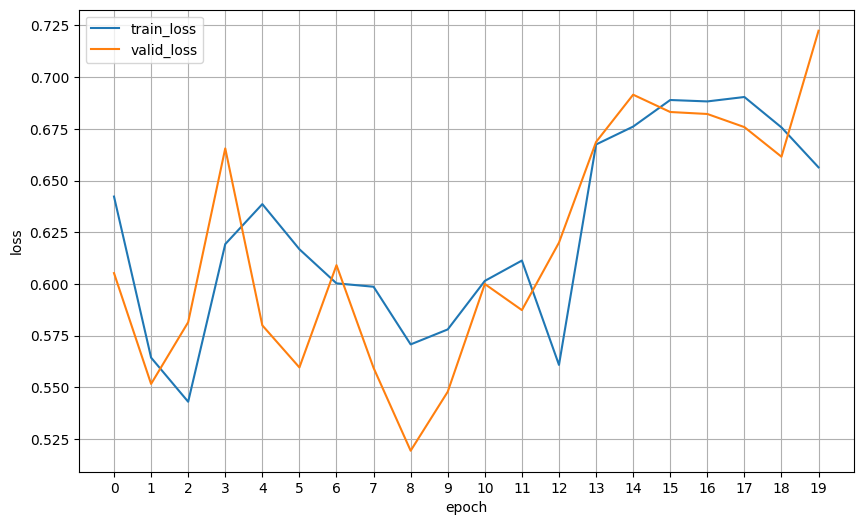

In [85]:
fig=plt.figure(figsize=(10,6))
ax=fig.add_subplot(1,1,1)
ax.plot(metrics["train_losses"],label="train_loss")
ax.plot(metrics["valid_losses"],label="valid_loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

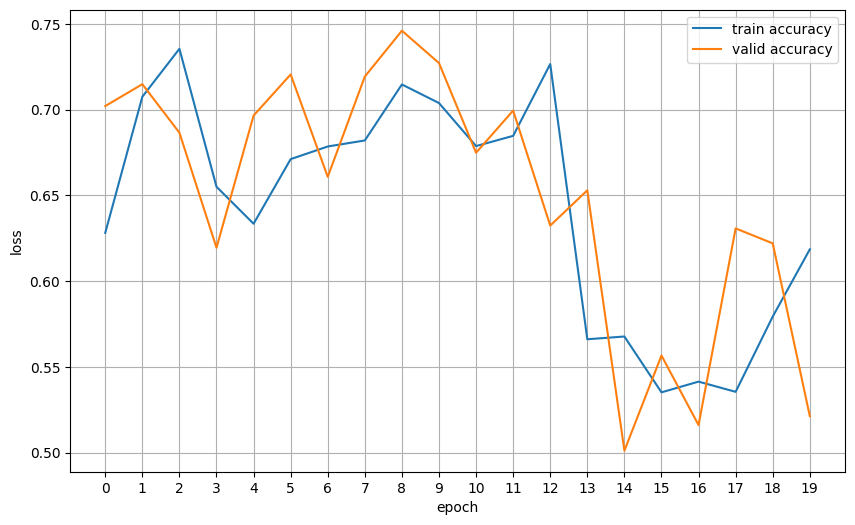

In [86]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(metrics["train_accs"], label="train accuracy")
ax.plot(metrics["valid_acc"], label="valid accuracy")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.set_xticks(range(n_epochs))
ax.legend()
ax.grid()

In [87]:
model.load_state_dict(torch.load("nbow.pt"))
test_loss,test_acc=evaluate(test_loader,model,criterion,device)

In [88]:
print(f"test_loss: {test_loss:.3f},test_acc:{test_acc:.3f}")

test_loss: 0.519,test_acc:0.754
